In [ ]:
# =============================================================================
# ANÁLISIS ESPECTRAL DE SERIES FINANCIERAS PARA CNN
# Ejecutar en Jupyter Notebook o Google Colab, celda por celda
# =============================================================================

# ── CELDA 1: Instalación de dependencias ─────────────────────────────────────
# (Descomentar si hace falta instalar)
!pip install yfinance mplfinance scipy pywavelets



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.3 MB/s eta 0:00:00


In [ ]:

# ── CELDA 2: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import yfinance as yf
from scipy import signal
from scipy.fft import fft, fftfreq
import pywt  # PyWavelets para Transformada de Wavelet
import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [ ]:

# ── CELDA 11: Instalación ─────────────────────────────────────────────────────
!pip install torch torchvision scikit-learn matplotlib seaborn


In [ ]:

# ── CELDA 12: Imports ─────────────────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Usando: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


✅ Usando: cuda
   GPU: Tesla T4


In [ ]:

# ── CELDA 13: Configuración global ───────────────────────────────────────────
DATASET_DIR  = "dataset_stft"
IMG_SIZE     = 64        # Debe coincidir con el tamaño generado antes
BATCH_SIZE   = 32
EPOCHS       = 40
LR           = 3e-4      # Learning rate inicial
LR_PATIENCE  = 5         # Epochs sin mejora para reducir LR
EARLY_STOP   = 12        # Epochs sin mejora para detener entrenamiento
CLASSES      = ["BUY", "HOLD", "SELL", "AVOID"]   # Orden alfabético = orden de PyTorch


In [ ]:
class SpectrogramDataset(Dataset):
    def __init__(self, csv_path, img_dir, horizon, transform=None):
        self.df        = pd.read_csv(csv_path)
        self.img_dir   = img_dir
        self.label_col = f"label_{horizon}d"
        self.classes   = ["AVOID", "BUY", "HOLD", "SELL"]  # orden fijo
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(os.path.join(self.img_dir, row["filename"])).convert("RGB")
        label = self.classes.index(row[self.label_col])
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:

# ── CELDA 14: Data augmentation y loaders ─────────────────────────────────────
# ⚠️  NO usar flip horizontal (invierte el tiempo)
# ⚠️  NO usar flip vertical (invierte frecuencias)
# ✅  Sí se puede: pequeñas rotaciones, jitter de color, ruido

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),  # Leve desplazamiento
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Dividir dataset en train (70%) / val (15%) / test (15%)
full_dataset = datasets.ImageFolder(DATASET_DIR, transform=train_tf)
n_total      = len(full_dataset)
n_train      = int(0.70 * n_total)
n_val        = int(0.15 * n_total)
n_test       = n_total - n_train - n_val

train_ds, val_ds, test_ds = torch.utils.data.random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Aplicar transforms correctos a val y test (sin augmentation)
val_ds.dataset  = datasets.ImageFolder(DATASET_DIR, transform=val_tf)
test_ds.dataset = datasets.ImageFolder(DATASET_DIR, transform=val_tf)

# Manejar desbalance de clases con WeightedRandomSampler
train_labels = [full_dataset.targets[i] for i in train_ds.indices]
class_counts = Counter(train_labels)
total_train  = sum(class_counts.values())
class_weights = {cls: total_train / count for cls, count in class_counts.items()}
sample_weights = [class_weights[lbl] for lbl in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=0, pin_memory=True)

print(f"📦 Dataset total : {n_total} imágenes")
print(f"   Train         : {n_train}")
print(f"   Val           : {n_val}")
print(f"   Test          : {n_test}")
print(f"\n📊 Distribución de clases:")
for idx, cls in enumerate(CLASSES):
    print(f"   {cls:5s}: {class_counts.get(idx, 0):4d} muestras")


📦 Dataset total : 659 imágenes
   Train         : 461
   Val           : 98
   Test          : 100

📊 Distribución de clases:
   DOWN :  156 muestras
   HOLD :  121 muestras
   UP   :  184 muestras


In [ ]:

# ── CELDA 15: Arquitectura CNN ────────────────────────────────────────────────
# Dos opciones. Elegí una descomentando el bloque correspondiente.

# ─── OPCIÓN A: CNN Custom liviana (ideal si el dataset es pequeño < 5000 imgs)

class SpectrogramCNN(nn.Module):
    """
    CNN de 4 bloques convolucionales diseñada para espectrogramas 64×64.
    Cada bloque: Conv → BN → ReLU → Conv → BN → ReLU → MaxPool → Dropout
    """
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()

        def conv_block(in_ch, out_ch, pool=True, drop=0.2):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool2d(2, 2))
            layers.append(nn.Dropout2d(drop))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            conv_block(3,   32,  pool=True,  drop=0.1),   # → 32×32
            conv_block(32,  64,  pool=True,  drop=0.15),  # → 16×16
            conv_block(64,  128, pool=True,  drop=0.2),   # → 8×8
            conv_block(128, 256, pool=True,  drop=0.25),  # → 4×4
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((2, 2)),    # → 256×2×2 = 1024
            nn.Flatten(),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ─── OPCIÓN B: Transfer Learning con ResNet18 (mejor si el dataset es grande)
# Descomenta este bloque y comenta la instanciación de SpectrogramCNN abajo

# class ResNetFinancial(nn.Module):
#     def __init__(self, num_classes=3, freeze_backbone=True):
#         super().__init__()
#         base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
#         if freeze_backbone:
#             for param in list(base.parameters())[:-10]:
#                 param.requires_grad = False
#         in_features = base.fc.in_features
#         base.fc = nn.Sequential(
#             nn.Linear(in_features, 128),
#             nn.ReLU(),
#             nn.Dropout(0.4),
#             nn.Linear(128, num_classes)
#         )
#         self.model = base
#     def forward(self, x):
#         return self.model(x)

# ── Instanciar modelo ────────────────────────────────────────────────────────
model = SpectrogramCNN(num_classes=len(CLASSES)).to(DEVICE)
# model = ResNetFinancial(num_classes=len(CLASSES)).to(DEVICE)   # ← Opción B

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\n🔢 Parámetros totales     : {total_params:,}")
print(f"   Parámetros entrenables : {trainable_params:,}")


SpectrogramCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout2d(p=0.1, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inpl

In [ ]:

# ── CELDA 16: Loss, optimizador, schedulers ───────────────────────────────────
# Label smoothing para evitar que la red sea demasiado confiada
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

# Reduce LR cuando val_loss no mejora
scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=LR_PATIENCE)

# Warmup + cosine decay (opcional, descomenta si usás ResNet)
# scheduler_cosine = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)

print("✅ Optimizador y scheduler configurados")
print(f"   LR inicial: {LR}  |  Weight decay: 1e-4  |  Label smoothing: 0.1")


✅ Optimizador y scheduler configurados
   LR inicial: 0.0003  |  Weight decay: 1e-4  |  Label smoothing: 0.1


In [ ]:

# ── CELDA 17: Funciones de entrenamiento y evaluación ────────────────────────
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Evita exploding gradients
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels, all_probs


 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR
─────────────────────────────────────────────────────────────────
     1 |     1.1279 |    24.95% |   1.0950 |  38.78% |   3.00e-04 ◀ best
     2 |     1.1025 |    32.54% |   1.1099 |  21.43% |   3.00e-04  (no mejora 1/12)
     3 |     1.0983 |    34.92% |   1.0693 |  50.00% |   3.00e-04 ◀ best
     4 |     1.0964 |    34.71% |   1.0898 |  38.78% |   3.00e-04  (no mejora 1/12)
     5 |     1.0908 |    38.83% |   1.1021 |  30.61% |   3.00e-04  (no mejora 2/12)
     6 |     1.0776 |    41.21% |   1.0687 |  43.88% |   3.00e-04 ◀ best
     7 |     1.0705 |    44.90% |   1.0851 |  47.96% |   3.00e-04  (no mejora 1/12)
     8 |     1.0776 |    41.21% |   1.0933 |  34.69% |   3.00e-04  (no mejora 2/12)
     9 |     1.0734 |    46.20% |   1.0552 |  45.92% |   3.00e-04 ◀ best
    10 |     1.0480 |    44.69% |   1.0725 |  40.82% |   3.00e-04  (no mejora 1/12)
    11 |     1.0168 |    52.93% |   0.9975 |  55.10% |   3.00e-04 ◀ best

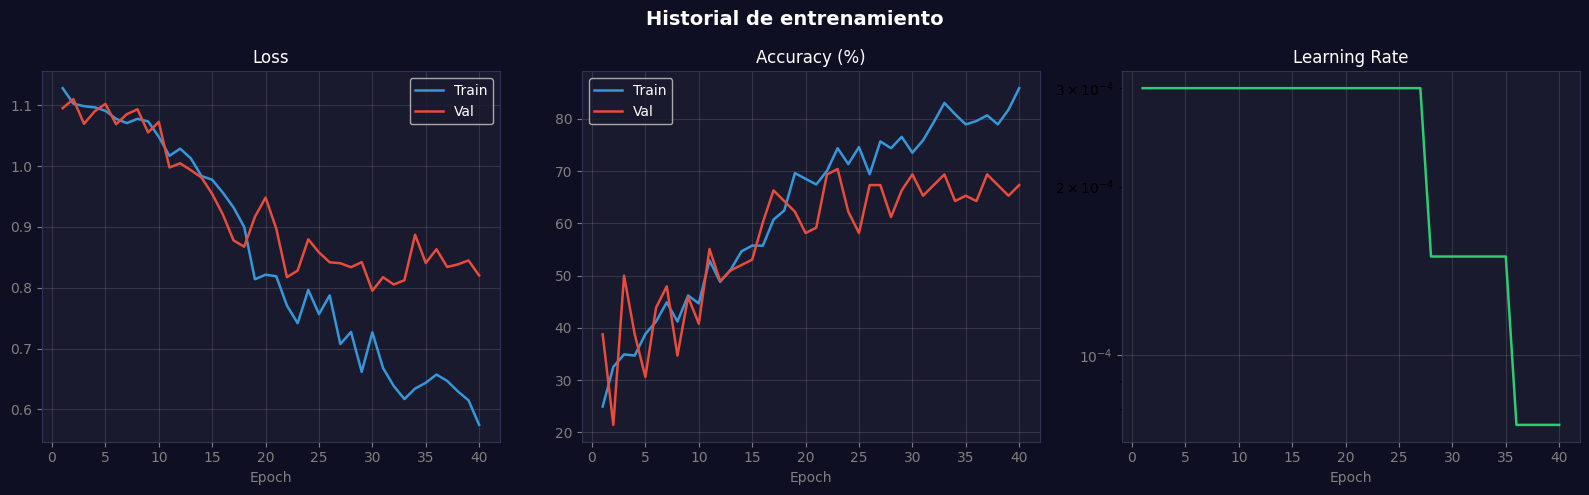

In [ ]:

# ── CELDA 18: Loop de entrenamiento ──────────────────────────────────────────
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "lr":         []
}

best_val_loss = float("inf")
best_weights  = None
patience_ctr  = 0

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>10}")
print("─" * 65)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc           = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, _, _, _  = eval_epoch(model, val_loader, criterion)

    scheduler_plateau.step(vl_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["lr"].append(current_lr)

    # Checkpoint del mejor modelo
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
        flag = " ◀ best"
    else:
        patience_ctr += 1
        flag = f"  (no mejora {patience_ctr}/{EARLY_STOP})"

    print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | {vl_loss:>8.4f} | {vl_acc*100:>6.2f}% | {current_lr:>10.2e}{flag}")

    if patience_ctr >= EARLY_STOP:
        print(f"\n⏹  Early stopping en epoch {epoch}")
        break

# Restaurar mejores pesos
model.load_state_dict(best_weights)
torch.save(best_weights, "spectrogram_cnn_best.pth")
print(f"\n✅ Mejor modelo guardado  |  Val Loss: {best_val_loss:.4f}")

# ── CELDA 19: Curvas de entrenamiento ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0f0f23")
fig.suptitle("Historial de entrenamiento", color="white", fontsize=14, fontweight="bold")

ep = range(1, len(history["train_loss"]) + 1)
colors = {"train": "#3498db", "val": "#e74c3c"}

# Loss
axes[0].plot(ep, history["train_loss"], color=colors["train"], label="Train", linewidth=1.8)
axes[0].plot(ep, history["val_loss"],   color=colors["val"],   label="Val",   linewidth=1.8)
axes[0].set_title("Loss", color="white")
axes[0].set_xlabel("Epoch", color="gray")
axes[0].legend(facecolor="#1a1a2e", labelcolor="white")

# Accuracy
axes[1].plot(ep, [a * 100 for a in history["train_acc"]], color=colors["train"], label="Train", linewidth=1.8)
axes[1].plot(ep, [a * 100 for a in history["val_acc"]],   color=colors["val"],   label="Val",   linewidth=1.8)
axes[1].set_title("Accuracy (%)", color="white")
axes[1].set_xlabel("Epoch", color="gray")
axes[1].legend(facecolor="#1a1a2e", labelcolor="white")

# Learning rate
axes[2].semilogy(ep, history["lr"], color="#2ecc71", linewidth=1.8)
axes[2].set_title("Learning Rate", color="white")
axes[2].set_xlabel("Epoch", color="gray")

for ax in axes:
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#333355")
    ax.grid(True, alpha=0.12, color="white")

plt.tight_layout()
plt.show()


In [ ]:

# ── CELDA 20: Evaluación en Test Set ─────────────────────────────────────────
test_loss, test_acc, preds, labels, probs = eval_epoch(model, test_loader, criterion)
probs  = np.array(probs)
preds  = np.array(preds)
labels = np.array(labels)

print(f"\n{'='*50}")
print(f"  TEST LOSS     : {test_loss:.4f}")
print(f"  TEST ACCURACY : {test_acc*100:.2f}%")
print(f"{'='*50}\n")
print(classification_report(labels, preds, target_names=CLASSES, digits=3))



  TEST LOSS     : 0.7068
  TEST ACCURACY : 78.00%

              precision    recall  f1-score   support

        DOWN      0.968     0.833     0.896        36
        HOLD      0.375     0.429     0.400        14
          UP      0.792     0.840     0.816        50

    accuracy                          0.780       100
   macro avg      0.712     0.701     0.704       100
weighted avg      0.797     0.780     0.786       100



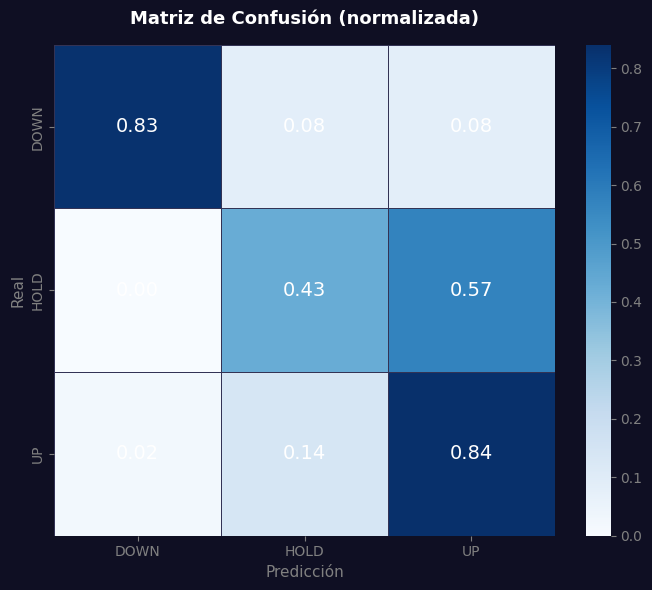

In [ ]:
# ── CELDA 21: Matriz de confusión ─────────────────────────────────────────────
cm = confusion_matrix(labels, preds, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#0f0f23")
ax.set_facecolor("#1a1a2e")

sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
    ax=ax, linewidths=0.5, linecolor="#333355",
    annot_kws={"size": 14, "color": "white"}
)
ax.set_title("Matriz de Confusión (normalizada)", color="white", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Predicción", color="gray", fontsize=11)
ax.set_ylabel("Real", color="gray", fontsize=11)
ax.tick_params(colors="gray")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="gray")

plt.tight_layout()
plt.show()

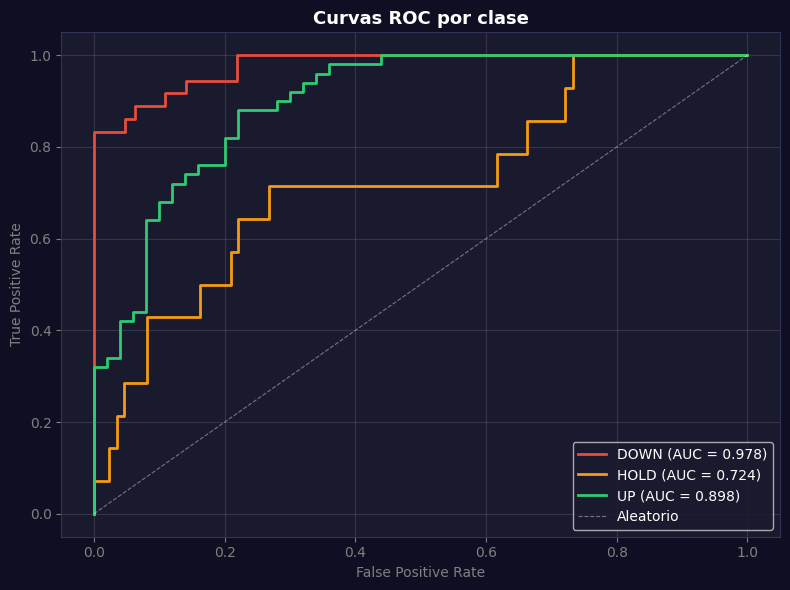

In [ ]:


# ── CELDA 22: Curvas ROC por clase ────────────────────────────────────────────
labels_bin = label_binarize(labels, classes=[0, 1, 2])
palette    = ["#e74c3c", "#f39c12", "#2ecc71"]

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0f0f23")
ax.set_facecolor("#1a1a2e")

for i, (cls, color) in enumerate(zip(CLASSES, palette)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{cls} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "w--", linewidth=0.8, alpha=0.4, label="Aleatorio")
ax.set_xlabel("False Positive Rate", color="gray")
ax.set_ylabel("True Positive Rate", color="gray")
ax.set_title("Curvas ROC por clase", color="white", fontsize=13, fontweight="bold")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
ax.tick_params(colors="gray")
ax.spines[:].set_color("#333355")
ax.grid(True, alpha=0.12, color="white")

plt.tight_layout()
plt.show()

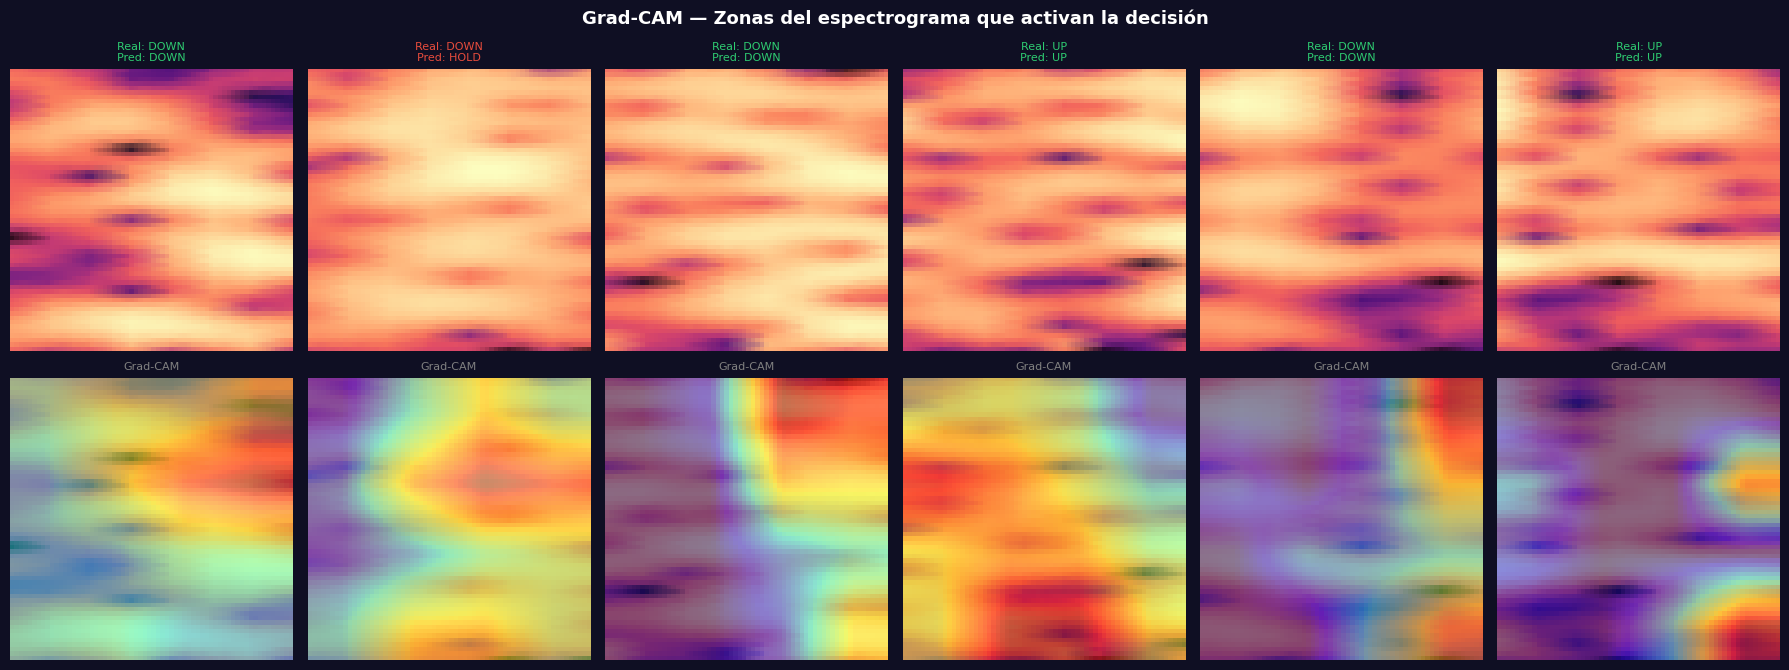

In [ ]:

# ── CELDA 23: Grad-CAM — ¿Qué parte del espectrograma mira la red? ────────────
# Implementación manual de Grad-CAM para la última capa convolucional

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, img_tensor, class_idx):
        self.model.eval()
        output = self.model(img_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = torch.clamp(cam, min=0)
        cam     = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy()


# Acceder a la última capa conv del modelo custom
target_layer = list(model.features[-1].children())[-2]  # Último Conv2d
grad_cam     = GradCAM(model, target_layer)

# Tomar 6 ejemplos del test set
sample_imgs, sample_labels = next(iter(DataLoader(test_ds, batch_size=6, shuffle=True)))
sample_imgs  = sample_imgs.to(DEVICE)
sample_preds = model(sample_imgs).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.patch.set_facecolor("#0f0f23")
fig.suptitle("Grad-CAM — Zonas del espectrograma que activan la decisión", color="white", fontsize=13, fontweight="bold")

unnorm = transforms.Normalize(mean=[-1, -1, -1], std=[2, 2, 2])

for col in range(6):
    img_t  = sample_imgs[col:col+1]
    pred   = sample_preds[col].item()
    true   = sample_labels[col].item()
    cam    = grad_cam.generate(img_t, pred)

    # Imagen original
    img_show = unnorm(sample_imgs[col]).cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    axes[0, col].imshow(img_show)
    axes[0, col].axis("off")
    color = "#2ecc71" if pred == true else "#e74c3c"
    axes[0, col].set_title(f"Real: {CLASSES[true]}\nPred: {CLASSES[pred]}", color=color, fontsize=8)

    # Grad-CAM superpuesto
    import cv2
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap     = plt.cm.jet(cam_resized)[:, :, :3]
    overlay     = 0.55 * img_show + 0.45 * heatmap
    axes[1, col].imshow(np.clip(overlay, 0, 1))
    axes[1, col].axis("off")
    axes[1, col].set_title("Grad-CAM", color="gray", fontsize=8)

for ax in axes.flat:
    ax.set_facecolor("#1a1a2e")

plt.tight_layout()
plt.show()


  🎯 Ticker        : BTC-USD
  📅 Ventana       : últimos 60 días
  🔮 Predicción    : HOLD
─────────────────────────────────────────────
  DOWN : ████                            15.2%
  HOLD : ███████████████████             65.4%
  UP   : █████                           19.4%


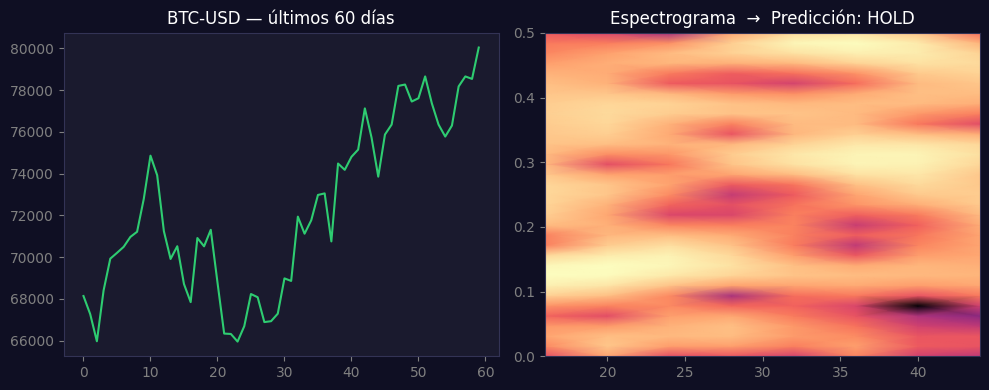


  🎯 Ticker        : AAPL
  📅 Ventana       : últimos 60 días
  🔮 Predicción    : UP
─────────────────────────────────────────────
  DOWN : █                                5.6%
  HOLD : ███████                         25.1%
  UP   : ████████████████████            69.3%


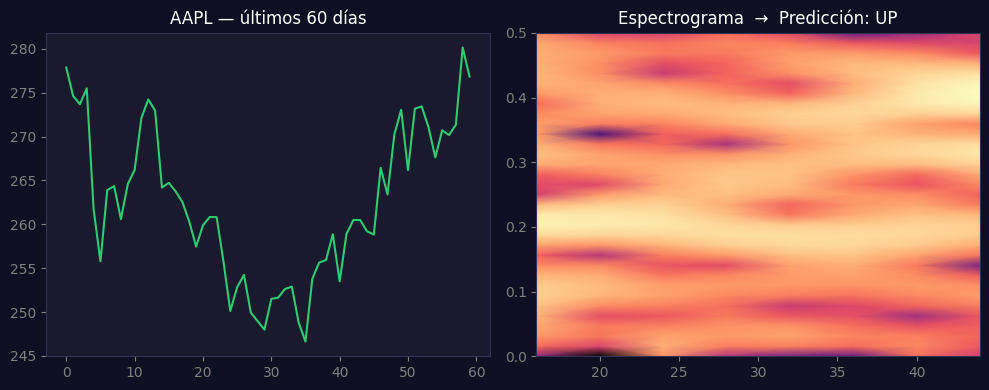


  🎯 Ticker        : SPY
  📅 Ventana       : últimos 60 días
  🔮 Predicción    : UP
─────────────────────────────────────────────
  DOWN : ████                            14.9%
  HOLD : ███                             13.2%
  UP   : █████████████████████           72.0%


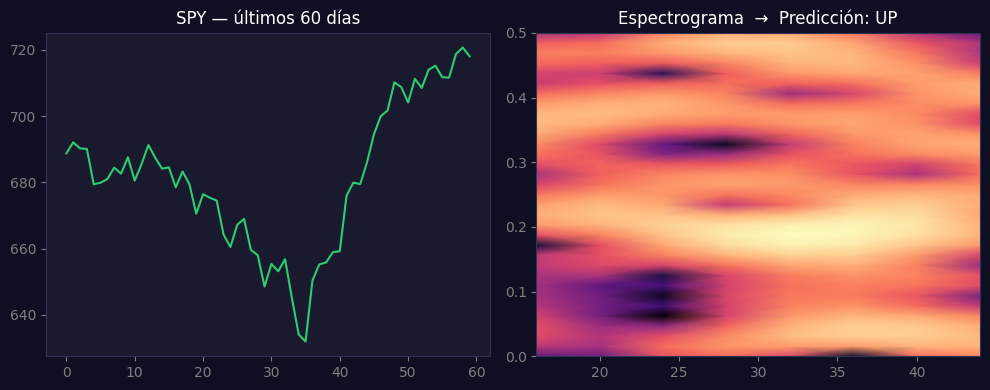

In [ ]:

# ── CELDA 24: Predicción en tiempo real sobre un nuevo ticker ─────────────────
import yfinance as yf
from scipy import signal as sig

def predecir_ticker(ticker, window_days=60):
    """Descarga los últimos datos y predice la dirección del próximo movimiento."""
    df_new  = yf.download(ticker, period="6mo", interval="1d", progress=False)
    close   = df_new["Close"].squeeze().values
    returns = np.diff(np.log(close))
    ret_n   = (returns - returns.mean()) / (returns.std() + 1e-8)

    if len(ret_n) < window_days:
        print(f"⚠️  No hay suficientes datos para {ticker}")
        return

    window = ret_n[-window_days:]
    f_w, t_w, S_w = sig.spectrogram(
        window, fs=1.0,
        window=sig.windows.hann(min(32, window_days)),
        noverlap=min(28, window_days - 1),
        nfft=64, scaling="density"
    )
    img_data = 10 * np.log10(S_w + 1e-12)

    # Convertir a tensor
    fig_tmp, ax_tmp = plt.subplots(figsize=(1, 1), dpi=64)
    ax_tmp.pcolormesh(t_w, f_w, img_data, cmap="magma", shading="gouraud")
    ax_tmp.axis("off")
    fig_tmp.subplots_adjust(left=0, right=1, top=1, bottom=0)
    tmp_path = f"/tmp/{ticker}_latest.png"
    fig_tmp.savefig(tmp_path, dpi=64, bbox_inches="tight", pad_inches=0)
    plt.close(fig_tmp)

    from PIL import Image
    img   = Image.open(tmp_path).convert("RGB")
    img_t = val_tf(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(img_t)
        probs_ = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = logits.argmax(dim=1).item()

    print(f"\n{'='*45}")
    print(f"  🎯 Ticker        : {ticker}")
    print(f"  📅 Ventana       : últimos {window_days} días")
    print(f"  🔮 Predicción    : {CLASSES[pred]}")
    print(f"{'─'*45}")
    for cls, p in zip(CLASSES, probs_):
        bar = "█" * int(p * 30)
        print(f"  {cls:5s}: {bar:<30} {p*100:5.1f}%")
    print(f"{'='*45}")

    # Mostrar el espectrograma que se usó
    fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
    fig2.patch.set_facecolor("#0f0f23")
    axes2[0].plot(df_new["Close"].squeeze().values[-window_days:], color="#2ecc71", linewidth=1.5)
    axes2[0].set_title(f"{ticker} — últimos {window_days} días", color="white")
    axes2[0].set_facecolor("#1a1a2e")
    axes2[0].tick_params(colors="gray")
    axes2[0].spines[:].set_color("#333355")

    axes2[1].pcolormesh(t_w, f_w, img_data, cmap="magma", shading="gouraud")
    axes2[1].set_title(f"Espectrograma  →  Predicción: {CLASSES[pred]}", color="white")
    axes2[1].set_facecolor("#1a1a2e")
    axes2[1].tick_params(colors="gray")
    axes2[1].spines[:].set_color("#333355")

    plt.tight_layout()
    plt.show()


# Probar con distintos activos
predecir_ticker("BTC-USD")
predecir_ticker("AAPL")
predecir_ticker("SPY")